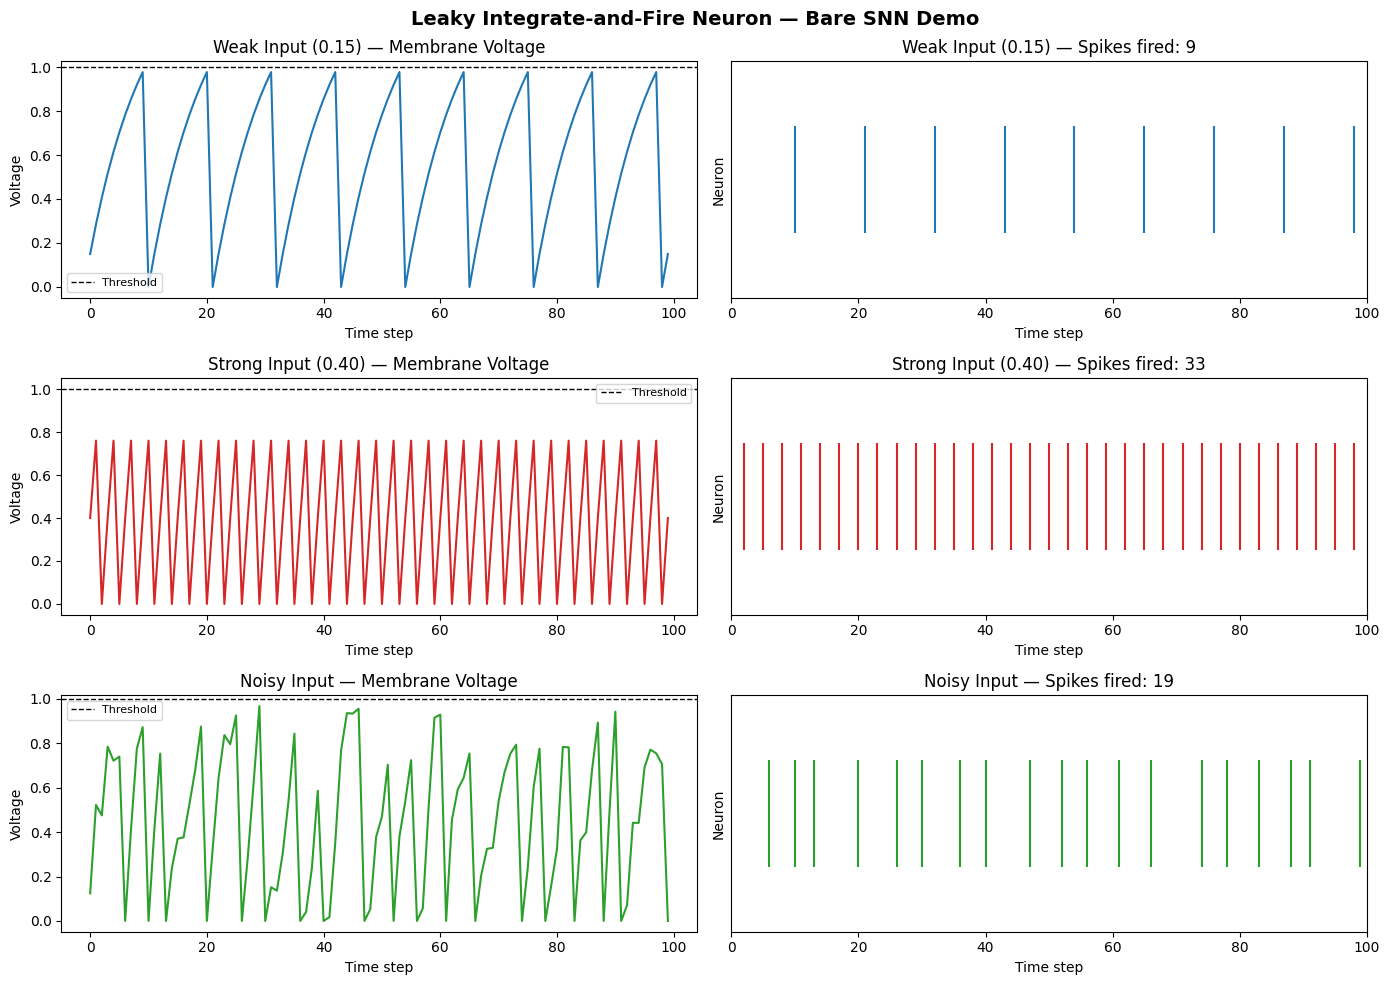


── Spike counts ──────────────────────────────
  Weak input   → 9 spikes in 100 timesteps
  Strong input → 33 spikes in 100 timesteps
  Noisy input  → 19 spikes in 100 timesteps

Key insight: MORE input = MORE spikes. That's how SNNs encode information.

── 2-Layer SNN Forward Pass ───────────────────
Input spikes per neuron: [19. 15. 17.]
Output neuron 1 fired: 16 times
Output neuron 2 fired: 17 times
Predicted class: Neuron 2 (most spikes wins!)


In [1]:
#  Simple SNN

import numpy as np
import matplotlib.pyplot as plt

# The LIF Neuron

def lif_neuron(input_current, timesteps=100, threshold=1.0, leak=0.9, reset=0.0):
    """
    Simulates ONE neuron over time.

    input_current : array of shape [timesteps] — how much input at each tick
    threshold     : voltage needed to fire
    leak          : how much voltage stays each tick (0.9 = 10% leaks away)
    """
    voltage = 0.0
    voltages = []
    spikes   = []

    for t in range(timesteps):
        voltage = voltage * leak

        voltage += input_current[t]

        if voltage >= threshold:
            spikes.append(1)
            voltage = reset
        else:
            spikes.append(0)

        voltages.append(voltage)

    return np.array(voltages), np.array(spikes)


# Run it with a constant low input
T = 100
# Weak input, neuron fires slowly
weak_input   = np.full(T, 0.15)
# Strong input, neuron fires rapidly
strong_input = np.full(T, 0.4)
# Noisy input, random spikes in, like real sensory data
noisy_input  = np.random.uniform(0, 0.5, T)

v_weak,   s_weak   = lif_neuron(weak_input)
v_strong, s_strong = lif_neuron(strong_input)
v_noisy,  s_noisy  = lif_neuron(noisy_input)

# Visualize
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle("Leaky Integrate-and-Fire Neuron — Bare SNN Demo", fontsize=14, fontweight='bold')

scenarios = [
    (v_weak,   s_weak,   weak_input,   "Weak Input (0.15)",   "tab:blue"),
    (v_strong, s_strong, strong_input, "Strong Input (0.40)", "tab:red"),
    (v_noisy,  s_noisy,  noisy_input,  "Noisy Input",         "tab:green"),
]

for i, (voltage, spikes, inp, title, color) in enumerate(scenarios):
    ax_v = axes[i][0]
    ax_s = axes[i][1]

    # Voltage trace
    ax_v.plot(voltage, color=color, linewidth=1.5)
    ax_v.axhline(1.0, color='black', linestyle='--', linewidth=1, label='Threshold')
    ax_v.set_title(f"{title} — Membrane Voltage")
    ax_v.set_ylabel("Voltage")
    ax_v.set_xlabel("Time step")
    ax_v.legend(fontsize=8)

    # Spike raster
    spike_times = np.where(spikes == 1)[0]
    ax_s.eventplot(spike_times, colors=color, linewidths=1.5)
    ax_s.set_title(f"{title} — Spikes fired: {spikes.sum()}")
    ax_s.set_ylabel("Neuron")
    ax_s.set_xlabel("Time step")
    ax_s.set_xlim(0, T)
    ax_s.set_yticks([])

plt.tight_layout()
plt.show()

print("\n── Spike counts ──────────────────────────────")
print(f"  Weak input   → {s_weak.sum()} spikes in {T} timesteps")
print(f"  Strong input → {s_strong.sum()} spikes in {T} timesteps")
print(f"  Noisy input  → {s_noisy.sum()} spikes in {T} timesteps")
print("\nKey insight: MORE input = MORE spikes. That's how SNNs encode information.")


# Mini 2-layer SNN (no training, just forward pass)
print("\n── 2-Layer SNN Forward Pass ───────────────────")

np.random.seed(42)

# Pretend we have 3 input neurons, 2 output neurons
# Weights are random (normally you'd train these)
W = np.array([[0.6, 0.3],
              [0.2, 0.8],
              [0.5, 0.4]])   # shape: [3 inputs, 2 outputs]

# Simulate input layer: 3 neurons spiking over 50 timesteps
T2 = 50
input_spikes = (np.random.rand(3, T2) < 0.3).astype(float)  # 30% firing rate

output_voltages = np.zeros(2)
output_spike_counts = np.zeros(2)

threshold = 1.0
leak = 0.85

print(f"Input spikes per neuron: {input_spikes.sum(axis=1)}")

for t in range(T2):
    # Each input neuron's spike × its weight → sums into each output neuron
    inp = input_spikes[:, t]          # [3]  — who fired this tick?
    current = inp @ W                 # [2]  — weighted input to each output neuron

    output_voltages = output_voltages * leak + current

    fired = output_voltages >= threshold
    output_spike_counts += fired
    output_voltages[fired] = 0.0      # reset neurons that fired

print(f"Output neuron 1 fired: {int(output_spike_counts[0])} times")
print(f"Output neuron 2 fired: {int(output_spike_counts[1])} times")
print(f"Predicted class: Neuron {np.argmax(output_spike_counts) + 1} (most spikes wins!)")